In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cell 2: Load Dataset

In [5]:
# Load the GDP dataset
file_path = '/content/drive/MyDrive/DATASETS_BIGDATA/GDP_factor cost_constant prices_Quarter_.xlsx'
df_gdp = pd.read_excel(file_path)

print(f"✅ Data loaded successfully")
print(f"   Shape: {df_gdp.shape[0]:,} rows, {df_gdp.shape[1]} columns")

✅ Data loaded successfully
   Shape: 34 rows, 14 columns


Cell 3: Explore Data Structure

In [9]:
print("Column names:")
print(df_gdp.columns.tolist())

print("\nFirst 5 rows:")
print(df_gdp.head())

print("\nLast 5 rows:")
print(df_gdp.tail())

Column names:
['GDP at Factor Cost  by Economic Activity - Constant Prices (mn LE)', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

First 5 rows:
  GDP at Factor Cost  by Economic Activity - Constant Prices (mn LE)  \
4                  Agriculture, Irrigation & Fishery                   
5                                        Extractions                   
6                                             a-Oil                    
7                                              b-Gas                   
8                                           c-Others                   

                Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
4  الزراعة والغابات والصيد        3.7      30243    30246.7        4.3   
5             الاستخراجات:      20769     4089.4    24858.4      21341   
6                أ) بترول        9349       1425      10774

Cell 4: Check Data Pattern

In [10]:
# Check what's in first column
print("First column values:")
print(df_gdp.iloc[:, 0].tolist())

First column values:
['Agriculture, Irrigation & Fishery', 'Extractions', 'a-Oil ', 'b-Gas', 'c-Others', 'Manufacturing Industries', 'a-Oil refining', 'b-Others', 'Electricity ', 'Water', 'Sanitation', 'Construction & Building ', 'Transportation & Storage', ' Communications', 'Information', 'Suez Canal', 'Wholesale & Retail Trade', 'Financial intermediaries & Auxiliary services', 'Insurance ', 'Social Security', 'Tourism', 'Real Estate Activities', 'a-Real Estate Property', 'b- Business Services', 'General Government', 'Education, Health & Personal Services', 'a-Education', 'b- Health', 'c-Others', 'Total GDP']


Cell 5: Filter Total GDP Row

In [11]:
# Filter the Total GDP row
total_gdp_row = df_gdp[df_gdp.iloc[:, 0] == 'Total GDP']

print("Total GDP Row:")
print(total_gdp_row)

Total GDP Row:
   GDP at Factor Cost  by Economic Activity - Constant Prices (mn LE)  \
33                                          Total GDP                   

                         Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4  \
33  الاجمالى العـــــــــــــــــام    67556.8     110390   177946.8   

   Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9 Unnamed: 10  \
33    67544.9     107499   175043.9    67920.3   107151.6    175071.9   

   Unnamed: 11 Unnamed: 12 Unnamed: 13  
33     71786.9    110537.1      182324  


Cell 6: Transpose and Clean Data

In [12]:
# Transpose the row to make quarters as rows
gdp_data = total_gdp_row.T.reset_index()
gdp_data.columns = ['Quarter', 'GDP_Value']

# Remove the first row (which was the column name)
gdp_data = gdp_data.iloc[1:].copy()

# Reset index
gdp_data = gdp_data.reset_index(drop=True)

print("GDP Data after transposing:")
print(gdp_data)

GDP Data after transposing:
        Quarter                        GDP_Value
0    Unnamed: 1  الاجمالى العـــــــــــــــــام
1    Unnamed: 2                          67556.8
2    Unnamed: 3                           110390
3    Unnamed: 4                         177946.8
4    Unnamed: 5                          67544.9
5    Unnamed: 6                           107499
6    Unnamed: 7                         175043.9
7    Unnamed: 8                          67920.3
8    Unnamed: 9                         107151.6
9   Unnamed: 10                         175071.9
10  Unnamed: 11                          71786.9
11  Unnamed: 12                         110537.1
12  Unnamed: 13                           182324


Cell 7: Clean Quarter Names and Convert to Numbers

In [13]:
# Extract quarter numbers from Unnamed columns
def clean_quarter(name):
    if 'Unnamed' in name:
        # Extract number from 'Unnamed: X'
        return int(name.split(':')[1])
    return name

gdp_data['Quarter_Num'] = gdp_data['Quarter'].apply(clean_quarter)

# Sort by quarter number
gdp_data = gdp_data.sort_values('Quarter_Num')

print("GDP Data with Quarter Numbers:")
print(gdp_data)

GDP Data with Quarter Numbers:
        Quarter                        GDP_Value  Quarter_Num
0    Unnamed: 1  الاجمالى العـــــــــــــــــام            1
1    Unnamed: 2                          67556.8            2
2    Unnamed: 3                           110390            3
3    Unnamed: 4                         177946.8            4
4    Unnamed: 5                          67544.9            5
5    Unnamed: 6                           107499            6
6    Unnamed: 7                         175043.9            7
7    Unnamed: 8                          67920.3            8
8    Unnamed: 9                         107151.6            9
9   Unnamed: 10                         175071.9           10
10  Unnamed: 11                          71786.9           11
11  Unnamed: 12                         110537.1           12
12  Unnamed: 13                           182324           13


Cell 8: Convert GDP to Numeric

In [14]:
# Convert GDP values to numeric
gdp_data['GDP'] = pd.to_numeric(gdp_data['GDP_Value'], errors='coerce')

# Drop any NaN values
gdp_data = gdp_data.dropna(subset=['GDP'])

print("Final GDP Data:")
print(gdp_data[['Quarter_Num', 'GDP']])

Final GDP Data:
    Quarter_Num       GDP
1             2   67556.8
2             3  110390.0
3             4  177946.8
4             5   67544.9
5             6  107499.0
6             7  175043.9
7             8   67920.3
8             9  107151.6
9            10  175071.9
10           11   71786.9
11           12  110537.1
12           13  182324.0


Cell 9: Feature Engineering 1 - Quarterly Growth Rate

In [15]:
# Calculate Quarterly Growth Rate
gdp_data['Quarterly_Growth'] = gdp_data['GDP'].pct_change() * 100

print("GDP Data with Growth Rate:")
print(gdp_data[['Quarter_Num', 'GDP', 'Quarterly_Growth']])

GDP Data with Growth Rate:
    Quarter_Num       GDP  Quarterly_Growth
1             2   67556.8               NaN
2             3  110390.0         63.403240
3             4  177946.8         61.198297
4             5   67544.9        -62.042082
5             6  107499.0         59.151912
6             7  175043.9         62.833050
7             8   67920.3        -61.198134
8             9  107151.6         57.760787
9            10  175071.9         63.387108
10           11   71786.9        -58.995761
11           12  110537.1         53.979487
12           13  182324.0         64.943716


Cell 10: Statistical Analysis

In [16]:
print("="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

gdp = gdp_data['GDP']
growth = gdp_data['Quarterly_Growth'].dropna()

print(f"\n📊 GDP Statistics (million LE):")
print(f"   Mean:   {gdp.mean():,.2f}")
print(f"   Median: {gdp.median():,.2f}")
print(f"   Std:    {gdp.std():,.2f}")
print(f"   Min:    {gdp.min():,.2f}")
print(f"   Max:    {gdp.max():,.2f}")

print(f"\n📈 Quarterly Growth Rate Statistics (%):")
print(f"   Mean Growth: {growth.mean():.2f}%")
print(f"   Max Growth:  {growth.max():.2f}%")
print(f"   Min Growth:  {growth.min():.2f}%")

STATISTICAL ANALYSIS

📊 GDP Statistics (million LE):
   Mean:   118,397.77
   Median: 108,944.50
   Std:    47,016.37
   Min:    67,544.90
   Max:    182,324.00

📈 Quarterly Growth Rate Statistics (%):
   Mean Growth: 27.67%
   Max Growth:  64.94%
   Min Growth:  -62.04%


Cell 11: Time-Series Plot

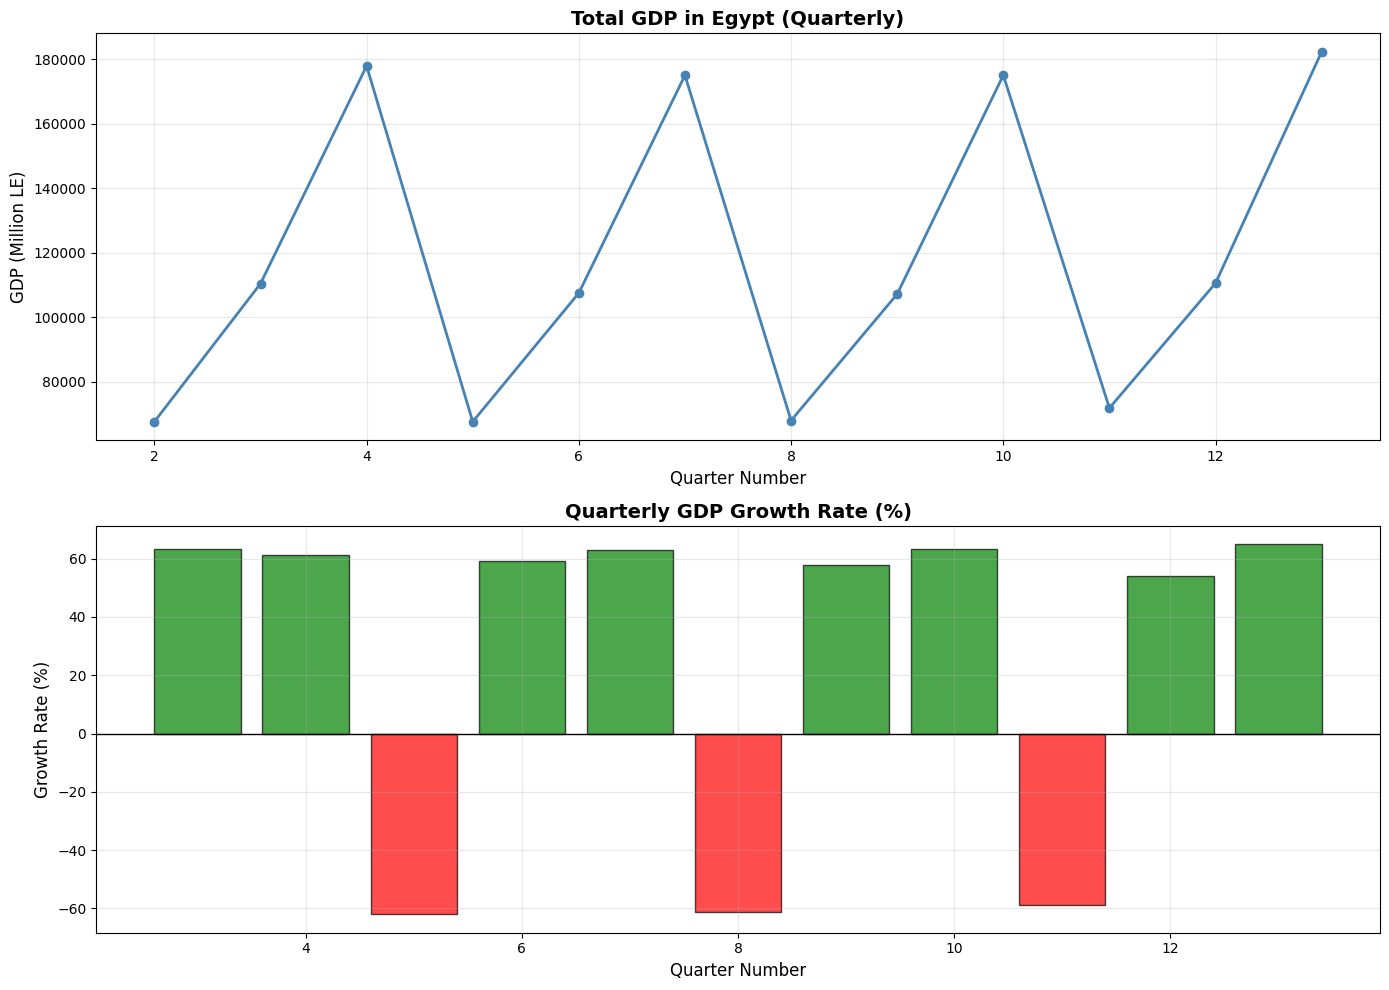

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: GDP over time
axes[0].plot(gdp_data['Quarter_Num'], gdp_data['GDP'], marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Total GDP in Egypt (Quarterly)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quarter Number', fontsize=12)
axes[0].set_ylabel('GDP (Million LE)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot 2: Quarterly Growth Rate
colors = ['green' if x >= 0 else 'red' for x in gdp_data['Quarterly_Growth']]
axes[1].bar(gdp_data['Quarter_Num'], gdp_data['Quarterly_Growth'], color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Quarterly GDP Growth Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter Number', fontsize=12)
axes[1].set_ylabel('Growth Rate (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cell 12: Key Insight - GDP Analysis

In [18]:
print("="*50)
print("KEY INSIGHT - GDP Analysis")
print("="*50)

latest_gdp = gdp_data['GDP'].iloc[-1]
avg_growth = growth.mean()
latest_growth = gdp_data['Quarterly_Growth'].iloc[-1]

print(f"""
Egypt's economic performance shows:

1. Latest GDP: {latest_gdp:,.2f} Million LE
2. Average Quarterly Growth: {avg_growth:.2f}%
3. Latest Quarterly Growth: {latest_growth:.2f}%
4. Overall GDP Trend: {'Increasing' if gdp.iloc[-1] > gdp.iloc[0] else 'Decreasing'}

Conclusion: Egypt's economy has shown {'growth' if gdp.iloc[-1] > gdp.iloc[0] else 'decline'}
over the analyzed period.

Recommendation: Digital transformation initiatives should be accelerated
during periods of positive economic growth to maximize adoption rates.
""")

KEY INSIGHT - GDP Analysis

Egypt's economic performance shows:

1. Latest GDP: 182,324.00 Million LE
2. Average Quarterly Growth: 27.67%
3. Latest Quarterly Growth: 64.94%
4. Overall GDP Trend: Increasing

Conclusion: Egypt's economy has shown growth 
over the analyzed period.

Recommendation: Digital transformation initiatives should be accelerated
during periods of positive economic growth to maximize adoption rates.



Cell 13: Outputs for Integration

In [19]:
print("="*60)
print("🎯 GDP - Final Output for Integration")
print("="*60)

print(f"""
┌────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                      GDP FINGERPRINT                                                               │
├────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 1. Latest GDP:                     {gdp.iloc[-1]:,.2f} Million LE                                  │
│ 2. Average GDP:                    {gdp.mean():,.2f} Million LE                                    │
│ 3. Average Quarterly Growth:       {growth.mean():.2f}%                                            │
│ 4. Latest Growth Rate:             {growth.iloc[-1]:.2f}%                                          │
│ 5. GDP Trend:                      {'Increasing' if gdp.iloc[-1] > gdp.iloc[0] else 'Decreasing'}  │
└────────────────────────────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ GDP FILE ANALYSIS COMPLETE")
print("\n🎉 ALL 5 FILES ANALYSIS COMPLETE! 🎉")

🎯 GDP - Final Output for Integration

┌────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                      GDP FINGERPRINT                                                               │
├────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 1. Latest GDP:                     182,324.00 Million LE                                  │
│ 2. Average GDP:                    118,397.77 Million LE                                    │
│ 3. Average Quarterly Growth:       27.67%                                            │
│ 4. Latest Growth Rate:             64.94%                                          │
│ 5. GDP Trend:                      Increasing  │
└────────────────────────────────────────────────────────────────────────────────────────────────────┘


✅ GDP FILE ANALYSIS COMPLETE

🎉 ALL 5 FILES ANALYSIS COMPLETE! 🎉
